In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from collections import Counter
import itertools
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
X_train=pd.read_csv('X_train.csv',index_col=False)
X_val=pd.read_csv('X_val.csv',index_col=False)
X_test=pd.read_csv('X_test.csv',index_col=False)
y_train=pd.read_csv('y_train.csv',index_col=False)
y_val=pd.read_csv('y_val.csv',index_col=False)
y_test=pd.read_csv('y_test.csv',index_col=False)

In [3]:
X_train.sample(5)

,Tweet,Cleaned_Tweet,Final_Cleaned_Tweet
96419,#cdnpoli #TruckersForFreedom #FreedomConvoy ht...,cannoli truckersforfreedom freedomconvoy,cannoli truckersforfreedom freedomconvoy
116394,Fair comment based on precedent: politicians a...,fair comment based on precedent politicians av...,fair comment base precedent politician avoid t...
82849,Yup.\nMembers of the .@OttawaPolice escorted t...,yup members of the escorted those in the freed...,yup member escort freedomconvoy wellington str...
124935,THE GREAT CANADIAN FREEDOM CONVOY https://t.co...,the great canadian freedom convoy,great canadian freedom convoy
129987,"@EloiMartel @nypost Well, didn't he donate $42...",well didn't he donate money to the freedom convoy,well n't donate money freedom convoy


## Lets explore the token lengths and vocabulary size of train set

In [4]:
# Step 1: Token length stats (for MAX_LEN)
X_train_tokens = X_train["Final_Cleaned_Tweet"].astype(str).apply(lambda x: len(x.split()))


In [5]:
X_train_tokens.head(2)

0    10
1    13
Name: Final_Cleaned_Tweet, dtype: int64

In [6]:
# Summary statistics for sequence lengths
max_len_stats = {
    "Min Length": X_train_tokens.min(),
    "Max Length": X_train_tokens.max(),
    "Mean Length": X_train_tokens.mean(),
    "Median Length": X_train_tokens.median(),
    "95th Percentile": X_train_tokens.quantile(0.95),
    "99th Percentile": X_train_tokens.quantile(0.99)
}


In [7]:
# Print recommended MAX_LEN based on 99th percentile
recommended_max_len = int(X_train_tokens.quantile(0.99))
print("Recommended MAX_LEN (99th percentile):", recommended_max_len)
print("Token Length Stats:", max_len_stats)

Recommended MAX_LEN (99th percentile): 30
Token Length Stats: {'Min Length': 1, 'Max Length': 108, 'Mean Length': 14.21446636317653, 'Median Length': 13.0, '95th Percentile': 26.0, '99th Percentile': 30.0}


In [8]:
# Fit tokenizer on raw training data
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train["Final_Cleaned_Tweet"].astype(str))


In [9]:
# Total number of unique words
vocab_size = len(tokenizer.word_index)
print("Actual Vocabulary Size (before cutoff):", vocab_size)

Actual Vocabulary Size (before cutoff): 55258


In [10]:

# Ensure all values are strings (replace NaN with empty string)
cleaned_tweets = X_train["Final_Cleaned_Tweet"].fillna("").astype(str)

# Tokenize and flatten all tokens
all_tokens = list(itertools.chain.from_iterable([text.split() for text in cleaned_tweets]))

# Count token frequencies
word_freq = Counter(all_tokens)

# Show top 10 most frequent words
most_common_words = word_freq.most_common(10)
print("Top 10 Most Common Words:", most_common_words)
print("Total Unique Words:", len(word_freq))

Top 10 Most Common Words: [('convoy', 132849), ('freedom', 129926), ('freedomconvoy', 56834), ('canada', 26997), ('ottawa', 26918), ('protest', 24624), ('trucker', 21853), ("'s", 21584), ('canadian', 20144), ('trudeau', 17925)]
Total Unique Words: 55260


## Lets Tokenazation and add padding to our input before feeding it to our model

In [11]:
# Parameters
MAX_VOCAB = 10000
MAX_LEN = 32

In [12]:
X_train_texts = X_train["Final_Cleaned_Tweet"].fillna("").astype(str).tolist()
X_val_texts   = X_val["Final_Cleaned_Tweet"].fillna("").astype(str).tolist()
X_test_texts  = X_test["Final_Cleaned_Tweet"].fillna("").astype(str).tolist()

In [13]:
X_train_texts[100]

"wow hurt canada reputation national security threat damn n't book freedomconvoy emergenciesactinquiry trudeaumustgo cannoli"

In [14]:
# Tokenizer setup
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")


In [15]:
tokenizer.fit_on_texts(X_train_texts)

In [16]:
# Convert texts to padded sequences
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_texts), maxlen=MAX_LEN, padding="post", truncating="post")
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val_texts), maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_texts), maxlen=MAX_LEN, padding="post", truncating="post")

In [17]:
# Label encoding
label_encoder = LabelEncoder()
y_train_enc = to_categorical(label_encoder.fit_transform(y_train["Sentiment"]))
y_val_enc   = to_categorical(label_encoder.transform(y_val["Sentiment"]))
y_test_enc  = to_categorical(label_encoder.transform(y_test["Sentiment"]))

In [18]:
y_test_enc[0]

array([0., 0., 1.], dtype=float32)

In [19]:
label_encoder.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [20]:
# Hyperparameters
MAX_VOCAB = 10000      # Top words to keep
MAX_LEN = 32           # Max sequence length
EMBED_DIM = 128        # Word/positional embedding size
NUM_HEADS = 4          # Multi-head attention heads
FF_DIM = 128           # Feedforward hidden layer
NUM_CLASSES = 3        # 'negative', 'neutral', 'positive'

# Lets build model layer by layer (positional embiddings layer , transformer layer , main block)

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models

def build_non_causal_transformer_model(max_len=32, vocab_size=10000, embed_dim=128, num_heads=4, ff_dim=128, num_classes=3):
    inputs = tf.keras.Input(shape=(max_len,), name="input_tokens")

    # Embedding + Positional Encoding
    embedding_layer = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)

    # Add positional encodings manually
    positions = tf.range(start=0, limit=max_len, delta=1)
    pos_encoding_layer = layers.Embedding(input_dim=max_len, output_dim=embed_dim)(positions)
    x = embedding_layer + pos_encoding_layer

    # Transformer block (non-causal, full attention)
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_output = layers.Dropout(0.3)(attn_output)  # 🔸 Dropout on transformer output
    attn_output = layers.LayerNormalization(epsilon=1e-6)(attn_output + x)

    # Feed-forward network
    ffn = layers.Dense(ff_dim, activation="relu")(attn_output)
    ffn = layers.Dropout(0.3)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(ffn + attn_output)

    # Global average pooling
    x = layers.GlobalAveragePooling1D()(x)

    # 🔸 Classifier Head (Deeper + Dropout + Regularization)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Compile with label smoothing
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )

    return model


In [22]:
model_2 = build_non_causal_transformer_model(
    max_len=MAX_LEN,            # e.g., 32
    vocab_size=MAX_VOCAB,       # e.g., 10000
    embed_dim=128,              # or 256
    num_heads=4,                # 2 or 4 heads is good for tweets
    ff_dim=128,                 # feed-forward units
    num_classes=3               # negative, neutral, positive
)
model_2.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_tokens (InputLayer)      [(None, 32)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 32, 128)      1280000     ['input_tokens[0][0]']           
                                                                                                  
 tf.__operators__.add (TFOpLamb  (None, 32, 128)     0           ['embedding[0][0]']              
 da)                                                                                              
                                                                                                  
 multi_head_attention (MultiHea  (None, 32, 128)     263808      ['tf.__operators__.add[0][0]'

In [23]:
# Tokenized + padded data (already one-hot encoded y_train_enc etc.)
history_2 = model_2.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=30,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/30
2873/2873 [==============================] - 29s 9ms/step - loss: 0.9599 - accuracy: 0.6686 - val_loss: 0.8336 - val_accuracy: 0.7085
Epoch 2/30
2873/2873 [==============================] - 23s 8ms/step - loss: 0.7651 - accuracy: 0.7262 - val_loss: 0.7579 - val_accuracy: 0.7273
Epoch 3/30
2873/2873 [==============================] - 23s 8ms/step - loss: 0.7347 - accuracy: 0.7470 - val_loss: 0.7500 - val_accuracy: 0.7323
Epoch 4/30
2873/2873 [==============================] - 72s 25ms/step - loss: 0.7122 - accuracy: 0.7606 - val_loss: 0.7523 - val_accuracy: 0.7397
Epoch 5/30
2873/2873 [==============================] - 87s 30ms/step - loss: 0.6919 - accuracy: 0.7728 - val_loss: 0.7569 - val_accuracy: 0.7386
Epoch 6/30
2873/2873 [==============================] - 30s 10ms/step - loss: 0.6747 - accuracy: 0.7838 - val_loss: 0.7427 - val_accuracy: 0.7437
Epoch 7/30
2873/2873 [==============================] - 24s 8ms/step - loss: 0.6607 - accuracy: 0.7918 - val_loss: 0.7485 - val

In [24]:


def evaluate_model(model,split_name, X_seq, y_enc):
    model=model
    y_pred_probs = model.predict(X_seq)
    y_pred_labels = y_pred_probs.argmax(axis=1)
    y_true_labels = y_enc.argmax(axis=1)
    
    print(f"\n Classification Report for {split_name}:")
    print(classification_report(y_true_labels, y_pred_labels, target_names=label_encoder.classes_))


In [25]:
def plot_multi_set_roc_auc(model, sets, labels, label_encoder):
    from sklearn.metrics import roc_curve, auc
    import matplotlib.pyplot as plt

    assert len(sets) == len(labels), "Mismatch in number of datasets and labels"

    n_classes = sets[0][1].shape[1]
    class_names = list(label_encoder.classes_)

    # Fixed colors for consistency
    fixed_colors = {
        "negative": "red",
        "neutral": "blue",
        "positive": "green"
    }
    default_colors = ["red", "blue", "green", "purple", "orange", "brown", "pink"]
    linestyles = ['-', '--', ':'][:len(sets)]

    plt.figure(figsize=(12, 8))

    # Predict once per dataset
    predictions = [model.predict(X_seq) for (X_seq, _) in sets]

    for class_idx in range(n_classes):
        class_label = class_names[class_idx]
        color = fixed_colors.get(class_label, default_colors[class_idx % len(default_colors)])

        for set_idx, ((_, y_enc), set_name) in enumerate(zip(sets, labels)):
            y_score = predictions[set_idx]
            fpr, tpr, _ = roc_curve(y_enc[:, class_idx], y_score[:, class_idx])
            roc_auc_score = auc(fpr, tpr)
            plt.plot(
                fpr, tpr,
                color=color,
                linestyle=linestyles[set_idx],
                label=f"{class_label} ({set_name}) AUC = {roc_auc_score:.2f}"
            )

    plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.5)")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC AUC per Class Across Sets")
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [26]:
# Prepare your sets
sets = [
    (X_train_seq, y_train_enc),
    (X_val_seq, y_val_enc),
    (X_test_seq, y_test_enc)
]
labels = ["Train", "Validation", "Test"]



In [27]:
def plot_train_val_history(history):
    """
    Plots training and validation loss and accuracy over epochs.
    """
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(14, 5))

    # --- Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Train Loss', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # --- Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy', color='orange')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


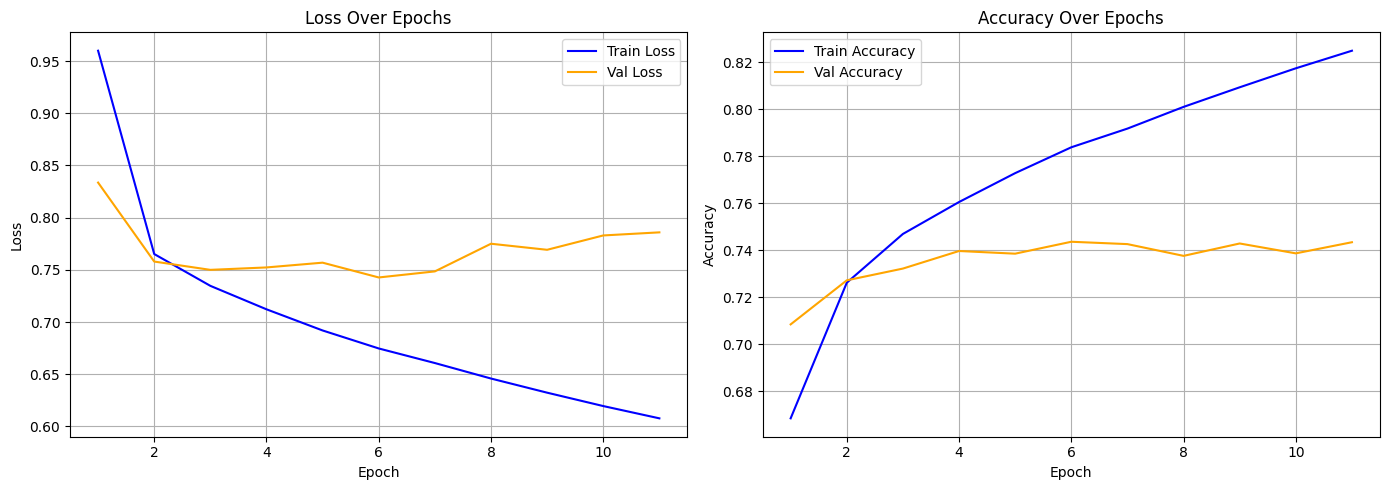

In [28]:
plot_train_val_history(history_2)

In [29]:
# Run on train, val, and test
evaluate_model(model_2,"Train", X_train_seq, y_train_enc)
evaluate_model(model_2,"Validation", X_val_seq, y_val_enc)
evaluate_model(model_2,"Test", X_test_seq, y_test_enc)

5746/5746 [==============================] - 13s 2ms/step

 Classification Report for Train:
              precision    recall  f1-score   support

    negative       0.80      0.83      0.81     61287
     neutral       0.90      0.68      0.78     61287
    positive       0.76      0.91      0.83     61287

    accuracy                           0.81    183861
   macro avg       0.82      0.81      0.81    183861
weighted avg       0.82      0.81      0.81    183861

469/469 [==============================] - 1s 3ms/step

 Classification Report for Validation:
              precision    recall  f1-score   support

    negative       0.74      0.78      0.76      5000
     neutral       0.81      0.59      0.68      5000
    positive       0.71      0.85      0.77      5000

    accuracy                           0.74     15000
   macro avg       0.75      0.74      0.74     15000
weighted avg       0.75      0.74      0.74     15000

625/625 [==============================] - 1s 2ms/

625/625 [==============================] - 2s 4ms/step


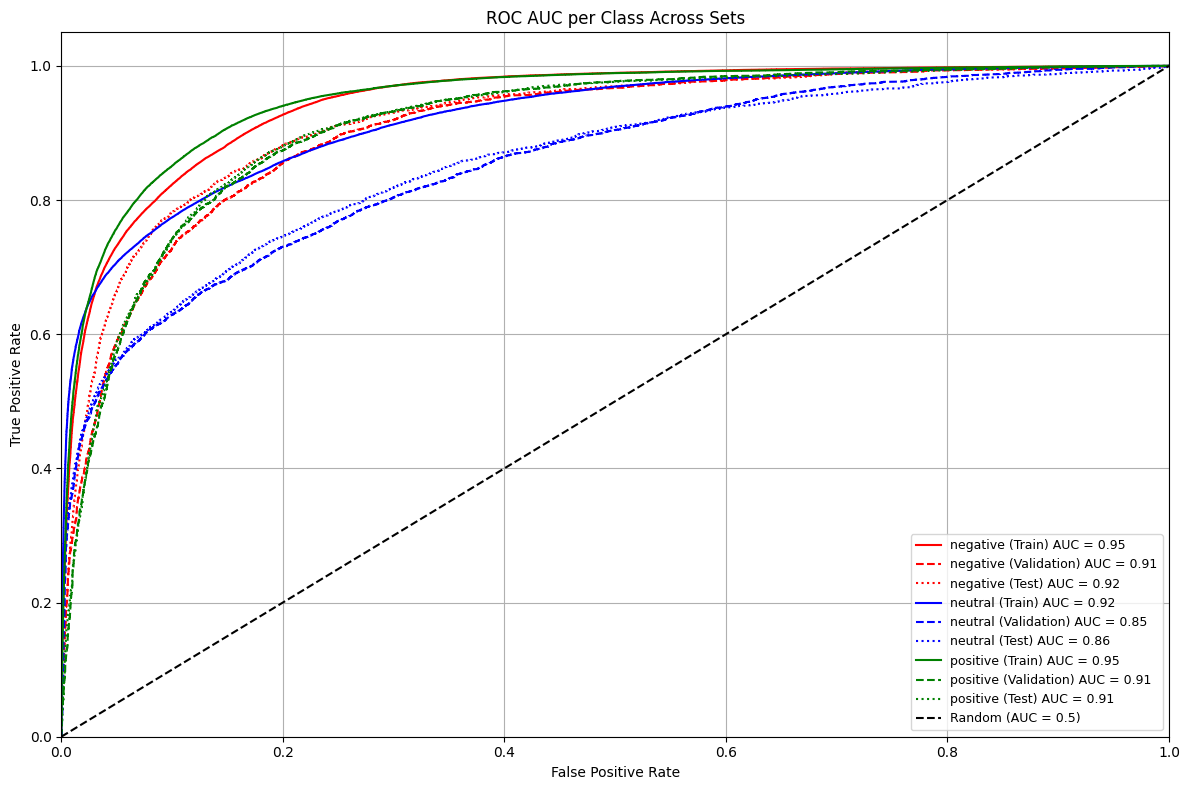

In [30]:
# Prepare your sets
sets = [
    (X_train_seq, y_train_enc),
    (X_val_seq, y_val_enc),
    (X_test_seq, y_test_enc)
]
labels = ["Train", "Validation", "Test"]

# Call the function
plot_multi_set_roc_auc(model_2, sets, labels, label_encoder)


In [31]:
import lime
from lime.lime_text import LimeTextExplainer
import numpy as np

# Make sure your label encoder is accessible
class_names = label_encoder.classes_

# Custom prediction wrapper for LIME
def predict_proba(texts):
    # Tokenize and pad input
    seq = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seq, maxlen=MAX_LEN)
    return model_2.predict(padded)

# Initialize LIME text explainer
explainer = LimeTextExplainer(class_names=class_names)

# Pick a sample to explain
sample_index = 3
sample_text = X_test.iloc[sample_index]["Final_Cleaned_Tweet"]
true_label = label_encoder.inverse_transform([np.argmax(y_test_enc[sample_index])])[0]

# Explain
exp = explainer.explain_instance(sample_text, predict_proba, num_features=10, top_labels=3)

# Show explanation in notebook
print(f"True label: {true_label}")
exp.show_in_notebook(text=sample_text)

# Or save HTML
# exp.save_to_file("lime_explanation.html")


157/157 [==============================] - 1s 6ms/step
True label: positive


## Tuning 1

Attention-based Pooling
We added an AttentionPooling1D layer to help the model focus on the most informative tokens in a sentence. Unlike GlobalAveragePooling1D, which averages all tokens, attention pooling gives weight to tokens that are more important for prediction.

Multiple Transformer Blocks
Included more than one Transformer block (e.g., num_transformer_blocks = 2). This allows the model to learn hierarchical and more abstract representations, which is beneficial for capturing complex patterns in text.

Cosine Decay Learning Rate
We used tf.keras.optimizers.schedules.CosineDecay to gradually reduce the learning rate over time. This strategy helps with smoother convergence and reduces the chances of overfitting or sudden divergence in training.

Advanced Regularization
The classifier head now includes:

Dropout: Randomly drops neurons during training to reduce reliance on any one feature.

BatchNormalization: Stabilizes and speeds up training by normalizing activations.

L2 Regularization: Penalizes large weights, encouraging simpler models.

Improved Optimizer Settings
We tuned the Adam optimizer by increasing the momentum term beta_1 to 0.95. This helps with smoother and more stable gradient updates, especially in deeper models.

Gradient Clipping
Applied clipnorm=1.0 to the optimizer. This prevents exploding gradients, which is important in models with attention layers where gradients can grow large.



In [50]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models

def build_model_5(
    max_len=32, vocab_size=10000, embed_dim=128, num_heads=4, ff_dim=128,
    num_classes=3, num_transformer_blocks=2
):
    inputs = tf.keras.Input(shape=(max_len,), name="input_tokens")

    # Embedding + Positional Encoding
    embedding_layer = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)
    positions = tf.range(start=0, limit=max_len, delta=1)
    pos_encoding_layer = layers.Embedding(input_dim=max_len, output_dim=embed_dim)(positions)
    x = embedding_layer + pos_encoding_layer

    # Attention-based pooling token
    cls_token = tf.Variable(tf.random.normal([1, 1, embed_dim]), trainable=True)
    cls_tokens = tf.tile(cls_token, [tf.shape(x)[0], 1, 1])
    x = tf.concat([cls_tokens, x], axis=1)

    # Transformer blocks
    for _ in range(num_transformer_blocks):
        attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
        attn_output = layers.Dropout(0.3)(attn_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

        ffn = layers.Dense(ff_dim, activation="relu")(x)
        ffn = layers.Dropout(0.3)(ffn)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)

    # Use the CLS token as representation
    cls_output = x[:, 0, :]  # First token

    # Classifier Head
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(cls_output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Cosine Decay + Momentum-based Adam
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=0.001,
        decay_steps=10000,
        alpha=0.1
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=0.95, beta_2=0.999)

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )

    return model

In [51]:

# Build and train model_5
model_5 = build_model_5(
    max_len=MAX_LEN,
    vocab_size=MAX_VOCAB,
    embed_dim=128,
    num_heads=4,
    ff_dim=128,
    num_classes=3,
    num_transformer_blocks=2
)

model_5.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_tokens (InputLayer)      [(None, 32)]         0           []                               
                                                                                                  
 embedding_8 (Embedding)        (None, 32, 128)      1280000     ['input_tokens[0][0]']           
                                                                                                  
 tf.__operators__.add_18 (TFOpL  (None, 32, 128)     0           ['embedding_8[0][0]']            
 ambda)                                                                                           
                                                                                                  
 tf.compat.v1.shape (TFOpLambda  (3,)                0           ['tf.__operators__.add_18[0

In [52]:

# Train the model
history_5 = model_5.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=30,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)


Epoch 1/30
2873/2873 [==============================] - 40s 13ms/step - loss: 1.0878 - accuracy: 0.6054 - val_loss: 0.8100 - val_accuracy: 0.6991
Epoch 2/30
2873/2873 [==============================] - 38s 13ms/step - loss: 0.7719 - accuracy: 0.7244 - val_loss: 0.7565 - val_accuracy: 0.7266
Epoch 3/30
2873/2873 [==============================] - 38s 13ms/step - loss: 0.7212 - accuracy: 0.7483 - val_loss: 0.7488 - val_accuracy: 0.7328
Epoch 4/30
2873/2873 [==============================] - 38s 13ms/step - loss: 0.6936 - accuracy: 0.7628 - val_loss: 0.7488 - val_accuracy: 0.7312
Epoch 5/30
2873/2873 [==============================] - 37s 13ms/step - loss: 0.6844 - accuracy: 0.7677 - val_loss: 0.7529 - val_accuracy: 0.7315
Epoch 6/30
2873/2873 [==============================] - 37s 13ms/step - loss: 0.6780 - accuracy: 0.7715 - val_loss: 0.7487 - val_accuracy: 0.7342
Epoch 7/30
2873/2873 [==============================] - 40s 14ms/step - loss: 0.6717 - accuracy: 0.7752 - val_loss: 0.7571 -

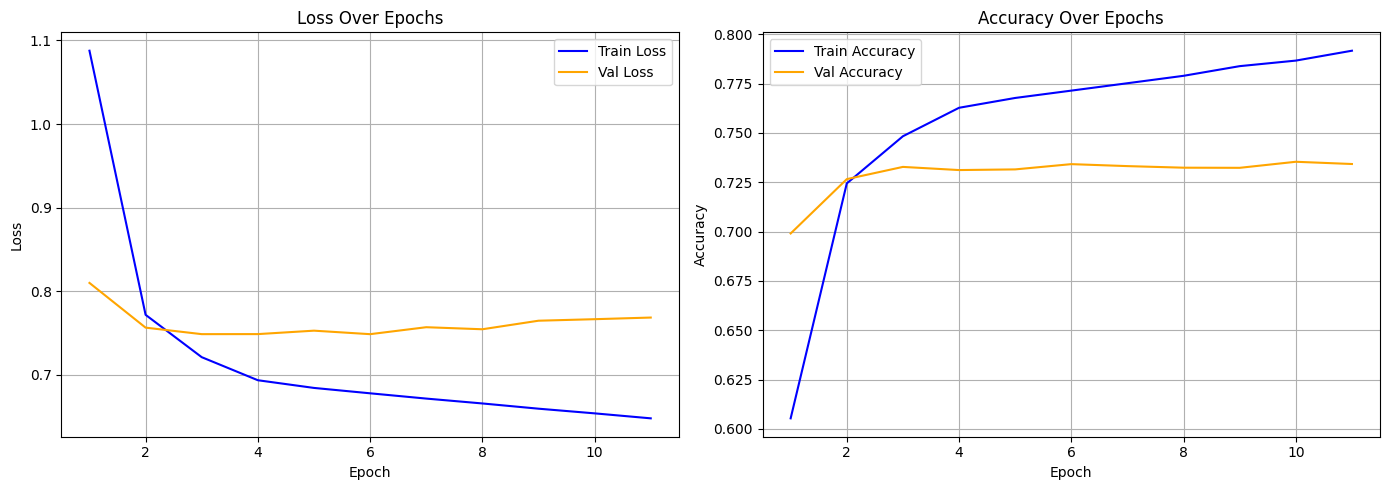

In [53]:
plot_train_val_history(history_5)

In [54]:
evaluate_model(model_5, "Train", X_train_seq, y_train_enc)
evaluate_model(model_5, "Validation", X_val_seq, y_val_enc)
evaluate_model(model_5, "Test", X_test_seq, y_test_enc)

5746/5746 [==============================] - 25s 4ms/step

 Classification Report for Train:
              precision    recall  f1-score   support

    negative       0.77      0.79      0.78     61287
     neutral       0.84      0.66      0.74     61287
    positive       0.75      0.89      0.81     61287

    accuracy                           0.78    183861
   macro avg       0.79      0.78      0.78    183861
weighted avg       0.79      0.78      0.78    183861

469/469 [==============================] - 2s 5ms/step

 Classification Report for Validation:
              precision    recall  f1-score   support

    negative       0.73      0.77      0.75      5000
     neutral       0.78      0.60      0.68      5000
    positive       0.71      0.84      0.77      5000

    accuracy                           0.73     15000
   macro avg       0.74      0.73      0.73     15000
weighted avg       0.74      0.73      0.73     15000

625/625 [==============================] - 3s 5ms/

625/625 [==============================] - 8s 13ms/step


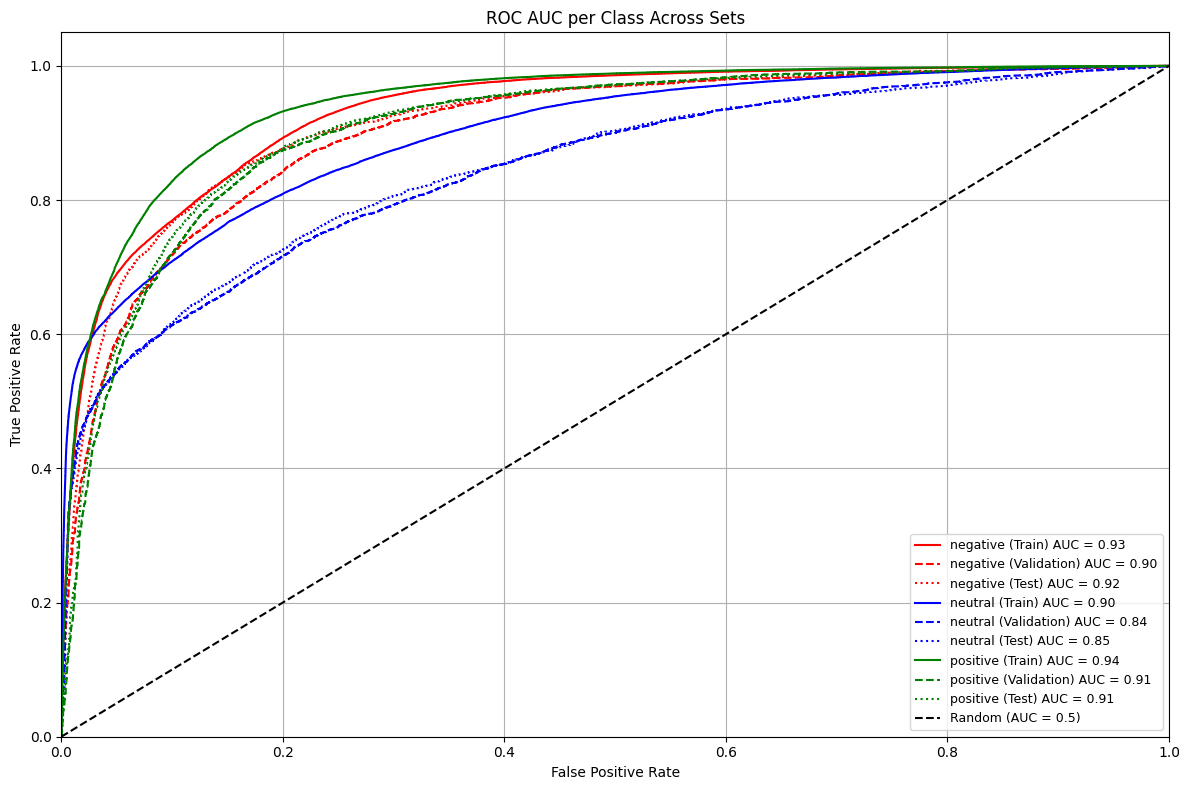

In [55]:
plot_multi_set_roc_auc(model_5, [(X_train_seq, y_train_enc), (X_val_seq, y_val_enc), (X_test_seq, y_test_enc)], ["Train", "Validation", "Test"], label_encoder)

In [71]:

def predict_proba_model_5(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=MAX_LEN)
    return model_5.predict(padded)

# 2. Setup LIME
class_names = label_encoder.classes_
explainer = LimeTextExplainer(class_names=class_names)

# 3. Choose a sample from the test set
sample_index = 3
sample_text = X_test.iloc[sample_index]["Final_Cleaned_Tweet"]
true_label = label_encoder.inverse_transform([np.argmax(y_test_enc[sample_index])])[0]

# 4. Explain
exp = explainer.explain_instance(sample_text, predict_proba_model_5, num_features=10, top_labels=3)

# 5. Show output
print(f"True label: {true_label}")
exp.show_in_notebook(text=sample_text)


157/157 [==============================] - 1s 4ms/step
True label: positive


## Tuning 2

Attention-based Pooling
Replaced GlobalAveragePooling1D with AttentionPooling1D to let the model focus on the most informative tokens instead of averaging all equally.

Multiple Transformer Blocks
Stacked 2+ transformer blocks to capture more complex, hierarchical patterns in the text.

Cosine Decay Learning Rate
Used tf.keras.optimizers.schedules.CosineDecay to gradually reduce the learning rate, improving convergence and reducing overfitting risk.

Advanced Regularization
Enhanced the classifier head with:

Dropout to prevent overfitting

BatchNormalization for training stability

L2 regularization to penalize large weights

Improved Optimizer Settings
Used Adam with higher momentum (beta_1 = 0.95) for smoother gradient updates.

Gradient Clipping
Applied clipnorm=1.0 to prevent exploding gradients in deep attention layers.

Freezing Base Layers (Tuning-specific)
Temporarily froze embedding layers to stabilize learning in early epochs, helping the classifier layers train more effectively.



In [ ]:


# Custom Attention Pooling
class AttentionPooling1D(layers.Layer):
    def __init__(self):
        super(AttentionPooling1D, self).__init__()

    def build(self, input_shape):
        self.w = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros", trainable=True)
        super(AttentionPooling1D, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.tensordot(x, self.w, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(x * a, axis=1)
        return output

# Focal Loss
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1 - 1e-8)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=-1))
    return loss

# Build Model 7
def build_model_7(max_len=32, vocab_size=10000, embed_dim=128, num_heads=4,
                  ff_dim=128, num_classes=3, num_transformer_blocks=2):
    inputs = tf.keras.Input(shape=(max_len,), name="input_tokens")

    # Embedding + Learnable Position Embedding
    embedding_layer = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, name="word_embedding")(inputs)
    positions = tf.range(start=0, limit=max_len, delta=1)
    pos_encoding_layer = layers.Embedding(input_dim=max_len, output_dim=embed_dim)(positions)
    x = embedding_layer + pos_encoding_layer  # No freezing of embeddings

    for _ in range(num_transformer_blocks):
        attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
        attn_output = layers.Dropout(0.3)(attn_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

        ffn = layers.Dense(ff_dim, activation="relu")(x)
        ffn = layers.Dropout(0.3)(ffn)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)

    # Attention Pooling
    x = AttentionPooling1D()(x)

    # Classifier head with regularization
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    lr_schedule = CosineDecay(initial_learning_rate=1e-3, decay_steps=1000)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=0.95, clipnorm=1.0)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizer,
                  loss=focal_loss(gamma=2.0, alpha=0.25),
                  metrics=["accuracy"])

    return model

In [65]:

# Instantiate and train
model_7 = build_model_7(
    max_len=MAX_LEN,
    vocab_size=MAX_VOCAB,
    embed_dim=128,
    num_heads=4,
    ff_dim=128,
    num_classes=3,
    num_transformer_blocks=2
)

model_7.summary()


Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_tokens (InputLayer)      [(None, 32)]         0           []                               
                                                                                                  
 word_embedding (Embedding)     (None, 32, 128)      1280000     ['input_tokens[0][0]']           
                                                                                                  
 tf.__operators__.add_28 (TFOpL  (None, 32, 128)     0           ['word_embedding[0][0]']         
 ambda)                                                                                           
                                                                                                  
 multi_head_attention_9 (MultiH  (None, 32, 128)     263808      ['tf.__operators__.add_28[0

In [66]:

history_7 = model_7.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=30,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)


Epoch 1/30
2873/2873 [==============================] - 58s 19ms/step - loss: 0.2355 - accuracy: 0.6222 - val_loss: 0.2007 - val_accuracy: 0.6647
Epoch 2/30
2873/2873 [==============================] - 48s 17ms/step - loss: 0.2041 - accuracy: 0.6544 - val_loss: 0.2005 - val_accuracy: 0.6639
Epoch 3/30
2873/2873 [==============================] - 110s 38ms/step - loss: 0.2041 - accuracy: 0.6526 - val_loss: 0.2006 - val_accuracy: 0.6643
Epoch 4/30
2873/2873 [==============================] - 51s 18ms/step - loss: 0.2040 - accuracy: 0.6537 - val_loss: 0.2005 - val_accuracy: 0.6644
Epoch 5/30
2873/2873 [==============================] - 97s 34ms/step - loss: 0.2041 - accuracy: 0.6544 - val_loss: 0.2005 - val_accuracy: 0.6646
Epoch 6/30
2873/2873 [==============================] - 47s 16ms/step - loss: 0.2041 - accuracy: 0.6552 - val_loss: 0.2005 - val_accuracy: 0.6643
Epoch 7/30
2873/2873 [==============================] - 45s 16ms/step - loss: 0.2042 - accuracy: 0.6548 - val_loss: 0.2004 

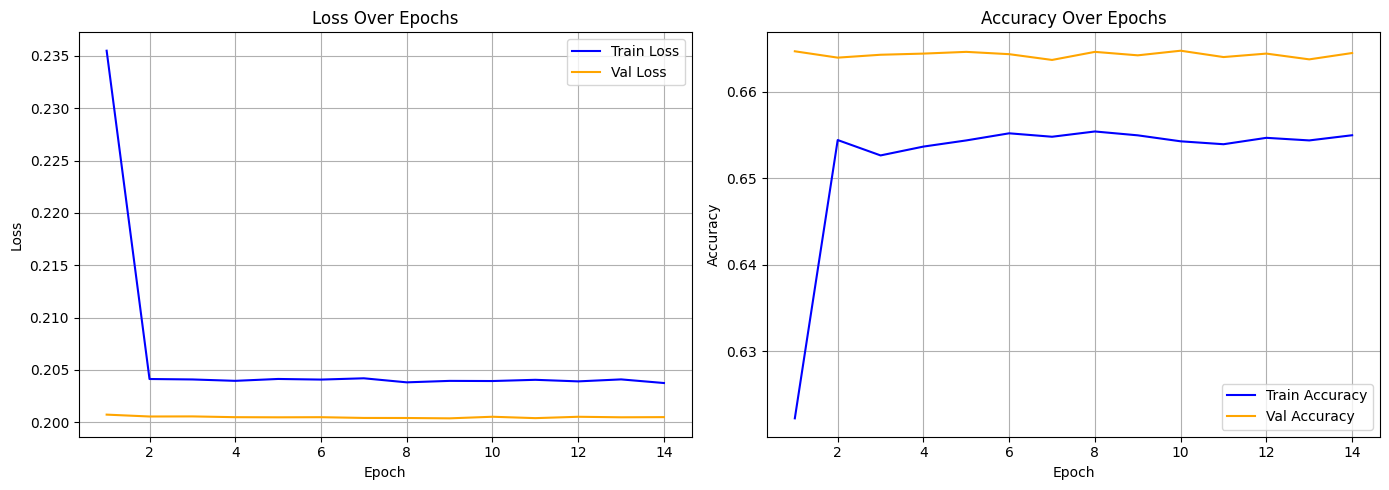

In [67]:
plot_train_val_history(history_7)

In [68]:
evaluate_model(model_7, "Train", X_train_seq, y_train_enc)
evaluate_model(model_7, "Validation", X_val_seq, y_val_enc)
evaluate_model(model_7, "Test", X_test_seq, y_test_enc)

5746/5746 [==============================] - 31s 5ms/step

 Classification Report for Train:
              precision    recall  f1-score   support

    negative       0.68      0.72      0.70     61287
     neutral       0.64      0.54      0.59     61287
    positive       0.70      0.77      0.74     61287

    accuracy                           0.68    183861
   macro avg       0.67      0.68      0.67    183861
weighted avg       0.67      0.68      0.67    183861

469/469 [==============================] - 2s 4ms/step

 Classification Report for Validation:
              precision    recall  f1-score   support

    negative       0.67      0.71      0.69      5000
     neutral       0.63      0.53      0.57      5000
    positive       0.68      0.75      0.72      5000

    accuracy                           0.66     15000
   macro avg       0.66      0.66      0.66     15000
weighted avg       0.66      0.66      0.66     15000

625/625 [==============================] - 3s 4ms/

625/625 [==============================] - 2s 4ms/step


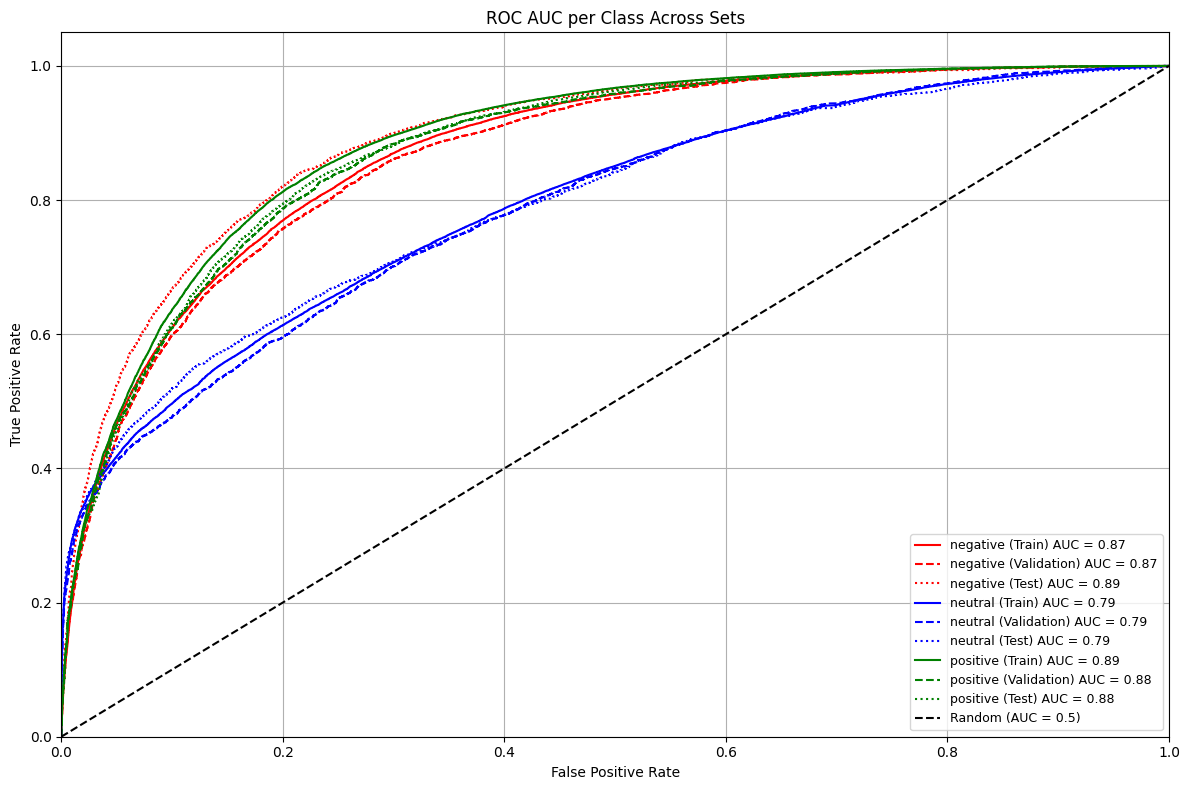

In [69]:
plot_multi_set_roc_auc(model_7, [(X_train_seq, y_train_enc), (X_val_seq, y_val_enc), (X_test_seq, y_test_enc)], ["Train", "Validation", "Test"], label_encoder)

In [70]:
from lime.lime_text import LimeTextExplainer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 1. Define prediction function for model_7
def predict_proba_model_7(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=MAX_LEN)
    return model_7.predict(padded)

# 2. Setup LIME text explainer
class_names = label_encoder.classes_
explainer = LimeTextExplainer(class_names=class_names)

# 3. Choose a sample from test set
sample_index = 3  # You can change this index to explore different samples
sample_text = X_test.iloc[sample_index]["Final_Cleaned_Tweet"]
true_label = label_encoder.inverse_transform([np.argmax(y_test_enc[sample_index])])[0]

# 4. Generate explanation
exp = explainer.explain_instance(
    sample_text,
    predict_proba_model_7,
    num_features=10,
    top_labels=3
)

# 5. Show explanation
print(f"True label: {true_label}")
exp.show_in_notebook(text=sample_text)


157/157 [==============================] - 1s 4ms/step
True label: positive


## Tuning 3

Attention-based Pooling
Continued using AttentionPooling1D to prioritize informative tokens over uniform averaging, improving interpretability and class separation.

Multiple Transformer Blocks
Retained 2 or more stacked Transformer layers to learn deeper contextual relationships in the text.

Cosine Decay Learning Rate
Used tf.keras.optimizers.schedules.CosineDecay for gradual learning rate reduction, aiding smoother convergence and reduced overfitting.

Advanced Regularization
Kept robust regularization in the classifier head:

Dropout to reduce overfitting

BatchNormalization to stabilize training

L2 regularization to prevent large weight magnitudes

Improved Optimizer Settings
Used Adam with beta_1 = 0.95 for higher momentum, helping the model make steadier weight updates across deeper layers.

Gradient Clipping
Applied clipnorm=1.0 to mitigate exploding gradients during backpropagation through attention layers.

Deeper Classifier Head (New in Model 8)
Added more Dense layers (e.g., 256 → 128 → 64 → 32) before the final output to give the model more capacity to learn complex decision boundaries.

GELU Activation (New in Model 8)
Switched from ReLU to GELU, a smoother activation function better suited for Transformer-style architectures — it helps the model generalize subtle variations in input.

In [ ]:
def AttentionPooling1D():
    def layer(inputs):
        weights = layers.Dense(1, activation="tanh")(inputs)
        weights = layers.Flatten()(weights)
        weights = layers.Activation("softmax")(weights)
        weights = layers.RepeatVector(inputs.shape[-1])(weights)
        weights = layers.Permute([2, 1])(weights)
        output = layers.Multiply()([inputs, weights])
        return layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(output)
    return layer

def build_model_8(
    max_len=32, vocab_size=10000, embed_dim=128, num_heads=4, ff_dim=128,
    num_classes=3, num_transformer_blocks=2
):
    inputs = tf.keras.Input(shape=(max_len,), name="input_tokens")

    # Embedding + Positional Encoding
    embedding_layer = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)
    positions = tf.range(start=0, limit=max_len, delta=1)
    pos_encoding_layer = layers.Embedding(input_dim=max_len, output_dim=embed_dim)(positions)
    x = embedding_layer + pos_encoding_layer

    # Transformer Blocks
    for _ in range(num_transformer_blocks):
        attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
        attn_output = layers.Dropout(0.3)(attn_output)
        x = layers.LayerNormalization(epsilon=1e-6)(attn_output + x)

        ffn = layers.Dense(ff_dim, activation="gelu")(x)
        ffn = layers.Dropout(0.3)(ffn)
        x = layers.LayerNormalization(epsilon=1e-6)(ffn + x)

    # Attention-based pooling
    x = AttentionPooling1D()(x)

    # Classifier Head (deeper)
    x = layers.Dense(256, activation="gelu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="gelu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="gelu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # Cosine Decay Learning Rate
    initial_lr = 1e-3
    decay_steps = 1000
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=decay_steps
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr_schedule,
        beta_1=0.95,
        clipnorm=1.0
    )

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )

    return model


In [73]:
model_8 = build_model_8(
    max_len=MAX_LEN,
    vocab_size=MAX_VOCAB,
    embed_dim=128,
    num_heads=4,
    ff_dim=128,
    num_classes=3,
    num_transformer_blocks=2
)

model_8.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_tokens (InputLayer)      [(None, 32)]         0           []                               
                                                                                                  
 embedding_11 (Embedding)       (None, 32, 128)      1280000     ['input_tokens[0][0]']           
                                                                                                  
 tf.__operators__.add_33 (TFOpL  (None, 32, 128)     0           ['embedding_11[0][0]']           
 ambda)                                                                                           
                                                                                                  
 multi_head_attention_11 (Multi  (None, 32, 128)     263808      ['tf.__operators__.add_33[0

In [74]:

history_8 = model_8.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=30,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)


Epoch 1/30
2873/2873 [==============================] - 61s 20ms/step - loss: 1.0862 - accuracy: 0.6606 - val_loss: 1.0173 - val_accuracy: 0.6903
Epoch 2/30
2873/2873 [==============================] - 51s 18ms/step - loss: 1.0271 - accuracy: 0.6920 - val_loss: 1.0172 - val_accuracy: 0.6901
Epoch 3/30
2873/2873 [==============================] - 49s 17ms/step - loss: 1.0266 - accuracy: 0.6919 - val_loss: 1.0177 - val_accuracy: 0.6893
Epoch 4/30
2873/2873 [==============================] - 49s 17ms/step - loss: 1.0265 - accuracy: 0.6918 - val_loss: 1.0169 - val_accuracy: 0.6900
Epoch 5/30
2873/2873 [==============================] - 50s 17ms/step - loss: 1.0265 - accuracy: 0.6915 - val_loss: 1.0169 - val_accuracy: 0.6901
Epoch 6/30
2873/2873 [==============================] - 48s 17ms/step - loss: 1.0262 - accuracy: 0.6919 - val_loss: 1.0170 - val_accuracy: 0.6899
Epoch 7/30
2873/2873 [==============================] - 50s 17ms/step - loss: 1.0267 - accuracy: 0.6915 - val_loss: 1.0169 -

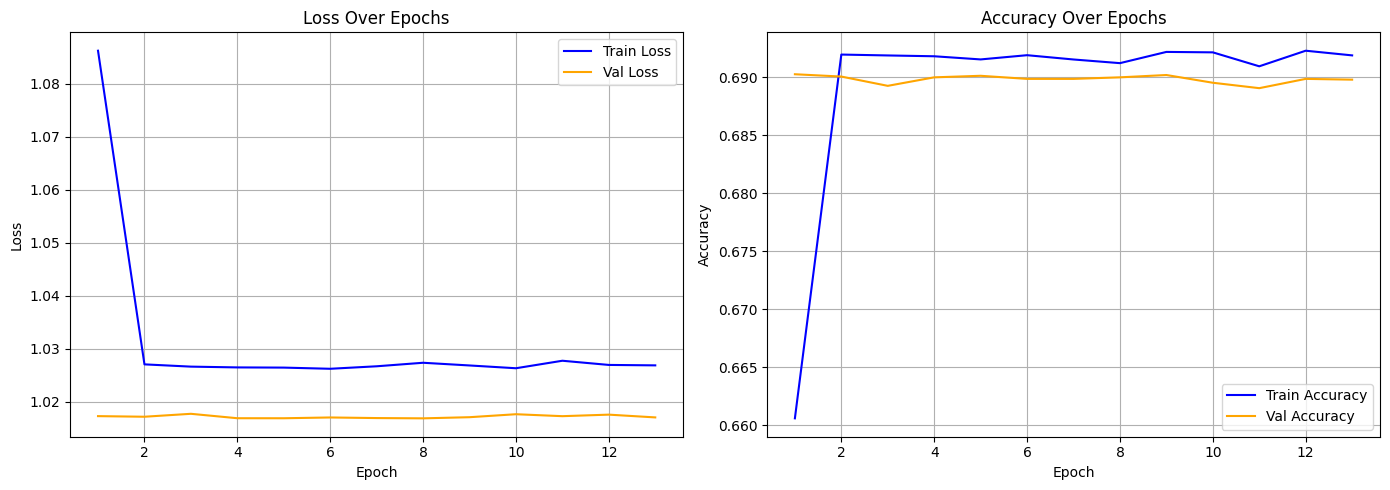

In [75]:
plot_train_val_history(history_8)

In [76]:
evaluate_model(model_8, "Train", X_train_seq, y_train_enc)
evaluate_model(model_8, "Validation", X_val_seq, y_val_enc)
evaluate_model(model_8, "Test", X_test_seq, y_test_enc)

5746/5746 [==============================] - 24s 4ms/step

 Classification Report for Train:
              precision    recall  f1-score   support

    negative       0.66      0.80      0.73     61287
     neutral       0.80      0.47      0.59     61287
    positive       0.69      0.83      0.75     61287

    accuracy                           0.70    183861
   macro avg       0.72      0.70      0.69    183861
weighted avg       0.72      0.70      0.69    183861

469/469 [==============================] - 2s 5ms/step

 Classification Report for Validation:
              precision    recall  f1-score   support

    negative       0.65      0.80      0.72      5000
     neutral       0.79      0.46      0.58      5000
    positive       0.68      0.81      0.74      5000

    accuracy                           0.69     15000
   macro avg       0.71      0.69      0.68     15000
weighted avg       0.71      0.69      0.68     15000

625/625 [==============================] - 2s 4ms/

625/625 [==============================] - 2s 4ms/step


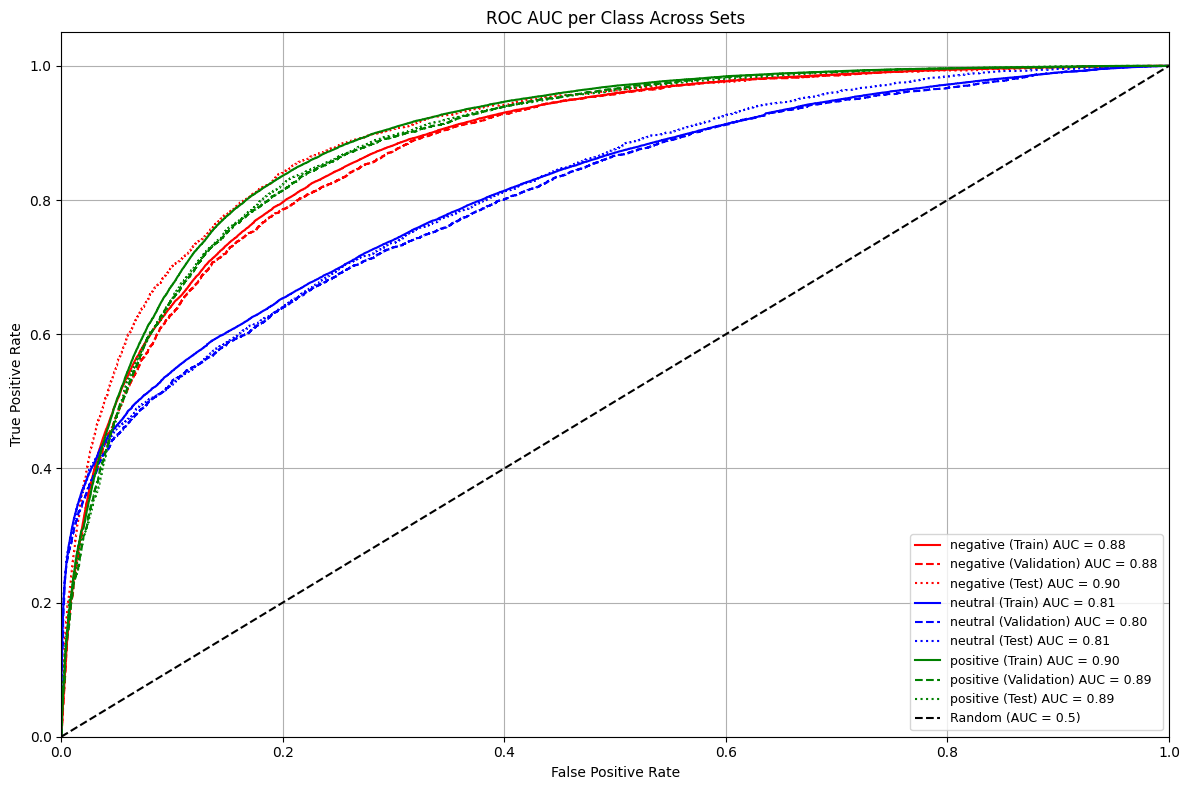

In [77]:
plot_multi_set_roc_auc(model_8, [(X_train_seq, y_train_enc), (X_val_seq, y_val_enc), (X_test_seq, y_test_enc)], ["Train", "Validation", "Test"], label_encoder)

In [95]:
def predict_proba_model_8(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=MAX_LEN)
    return model_8.predict(padded)

# 2. Setup LIME text explainer
class_names = label_encoder.classes_
explainer = LimeTextExplainer(class_names=class_names)

# 3. Choose a sample from test set
sample_index = 3  # You can change this index to explore different samples
sample_text = X_test.iloc[sample_index]["Final_Cleaned_Tweet"]
true_label = label_encoder.inverse_transform([np.argmax(y_test_enc[sample_index])])[0]

# 4. Generate explanation
exp = explainer.explain_instance(
    sample_text,
    predict_proba_model_8,
    num_features=10,
    top_labels=3
)

# 5. Show explanation
print(f"True label: {true_label}")
exp.show_in_notebook(text=sample_text)


157/157 [==============================] - 1s 5ms/step
True label: positive
